# Sneaker-Resale -- a quantitative teardown
### 18 years * ^GSPC * excess-return t * Newey-West HAC * Geltner AR(1) unsmoothing * n=18 power * synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We test whether the sneaker-resale index out-returns the S&P 500 (one-sample and **Newey-West HAC** t-tests on the annual excess), whether its high Sharpe survives **Geltner AR(1) unsmoothing**, what frictions do to it, and close with an n=18 power calculation and a synthetic positive control.

> **Not investment advice.** Real data: ^GSPC S&P 500 price index (2007–2024, Dec/Dec); sneaker index hardcoded in `data.py` (2006–2024). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sneaker_resale import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc_annual(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=18, year_start=2007, year_end=2024,
    sneaker_cagr_pct=7.0, gspc_cagr_pct=8.2,
    sneaker_mean_pct=7.5, sneaker_vol_pct=10.6,
    gspc_mean_pct=9.9, gspc_vol_pct=17.9,
    excess_mean_pct=-2.4, excess_t_ols=-0.567, excess_p_ols=0.5781, excess_t_hac=-0.58,
    sneaker_sharpe=0.71, gspc_sharpe=0.55,
    ar1_rho=0.63, unsmoothed_vol_pct=23.1, unsmoothed_sharpe=0.29,
    net_sneaker_mean_pct=4.5,
    strat_cagr_pct=9.3, bah_gspc_cagr_pct=8.2, trend_shortfall_pp=1.03,
)

from scipy import stats as scipy_stats


^GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Excess return **−2.4%/yr**, t = **−0.57**, Newey-West HAC t = **−0.58**. The high Sharpe is a stale-pricing artifact (AR(1) ρ = +0.63; unsmoothed Sharpe **0.29** < S&P 0.55). |
| **Tradability** | `MIRAGE` | No investable index; physical resale at ~10–15% one-way fees, no shorting; net ~+4.5%/yr. |
| **Busted?** | `YES` | A real boom-and-bust, but the 'beats stocks at lower risk' pitch is manufactured by smoothed appraisal pricing. |

> Sneakers under-returned the S&P; their only apparent edge -- risk-adjusted -- evaporates the moment you undo the smoothing.

## 1 - The claim, steelmanned

Let $r^{sn}_t$ and $r^{spx}_t$ be the calendar-year returns of the sneaker index and the S&P 500, and $x_t = r^{sn}_t - r^{spx}_t$ the annual excess. The pitch is:

- **H1 (return).** $E[x_t] > 0$ -- sneakers out-return stocks, distinguishable at |t| ≥ 2 (HAC) on the real tape.
- **H2 (risk-adjusted).** $\text{Sharpe}(r^{sn}) > \text{Sharpe}(r^{spx})$ on the *economic* (unsmoothed) return series, not just the reported one.
- **H3 (tradable).** The edge survives realistic one-way frictions and the absence of a short side / index vehicle.

We reject H1 (the point estimate is *negative*), reject H2 (it holds only on smoothed marks), and reject H3 (no vehicle, frictions halve the return).

## 2 - So what? -- what rides on each answer

If H1–H3 held, the sneaker market would be a rare investable free lunch and the 'stock market of things' branding would be literally true. The instructive finding is *how* an illiquid, smoothed collectible index manufactures an attractive Sharpe -- the same mechanism that flatters private real estate and hedge-fund NAVs (Asness-Krail-Liew 2001; Geltner 1991).

## 3 - How we'd know -- the protocol

- **Data.** ^GSPC December/December last-trading-day price returns 2007–2024 (repo-level cache, cache-only); sneaker index hardcoded in `data.py`.
- **Return test.** One-sample t on $x_t = r^{sn}_t - r^{spx}_t$ vs 0, plus a **Newey-West HAC** t (lag 1) -- the honest SE for a serially correlated annual series. **Signal bar: |HAC t| ≥ 2.**
- **Risk test.** First-order autocorrelation of $r^{sn}$, then **Geltner AR(1) unsmoothing** $r^{true}_t = (r_t - \rho r_{t-1})/(1-\rho)$; compare Sharpes.
- **Tradability.** One-way frictional cost on the sneaker leg; a lagged (no-look-ahead) momentum overlay vs buy-and-hold S&P.
- **Power + control.** n=18 minimum-detectable-effect; synthetic tape with a planted alpha and planted smoothing.


## 4 - The teardown

### 4a - Return: the annual excess and its (HAC) t-stat

The headline test: is the mean annual excess return different from zero?

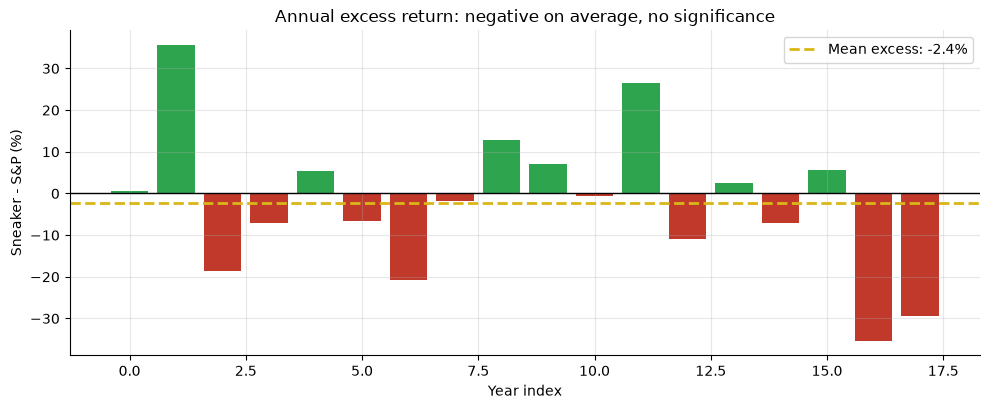

n = 18   mean excess = -2.4%/yr
One-sample t (vs 0): -0.567  (p = 0.5781)
Newey-West HAC t (lag 1): -0.580
|HAC t| < 2 -- and the sign is negative. No outperformance signal.


In [2]:
if HAVE_REAL:
    df = data.fetch_gspc_annual()
    c = st.compare_returns(df)
    excess = (df['sneaker_return'] - df['gspc_return']).values * 100
    n_obs = c['n']; ex_mean = c['excess_mean']*100
    t_ols = c['excess_t_ols']; p_ols = c['excess_p_ols']; t_hac = c['excess_t_hac']
else:
    rng = np.random.default_rng(276)
    snr = rng.normal(R['sneaker_mean_pct'], R['sneaker_vol_pct'], R['n'])
    gsr = rng.normal(R['gspc_mean_pct'], R['gspc_vol_pct'], R['n'])
    excess = snr - gsr
    n_obs = R['n']; ex_mean = R['excess_mean_pct']
    t_ols = R['excess_t_ols']; p_ols = R['excess_p_ols']; t_hac = R['excess_t_hac']

fig, ax = plt.subplots(figsize=(10, 4.2))
cols = [GREEN if e>0 else RED for e in excess]
ax.bar(range(len(excess)), excess, color=cols)
ax.axhline(0, c='k', lw=1)
ax.axhline(excess.mean(), ls='--', c=AMBER, lw=2, label=f'Mean excess: {excess.mean():+.1f}%')
ax.set_xlabel('Year index'); ax.set_ylabel('Sneaker - S&P (%)')
ax.set_title('Annual excess return: negative on average, no significance')
ax.legend(); plt.tight_layout(); plt.show()
print(f'n = {n_obs}   mean excess = {ex_mean:+.1f}%/yr')
print(f'One-sample t (vs 0): {t_ols:+.3f}  (p = {p_ols:.4f})')
print(f'Newey-West HAC t (lag 1): {t_hac:+.3f}')
print('|HAC t| < 2 -- and the sign is negative. No outperformance signal.')

> The point estimate is **−2.4%/yr**: sneakers *underperformed*. The HAC t-stat is **−0.58**, nowhere near the |t| ≥ 2 bar (and pointing the wrong way). H1 is rejected before we even worry about risk.

### 4b - The Sharpe illusion: AR(1) smoothing and Geltner unsmoothing

The sneaker index's low reported volatility is the heart of the pitch. We test whether it is real by measuring autocorrelation and unsmoothing.

In [3]:
if HAVE_REAL:
    snret = df['sneaker_return']
    uns, rho = st.unsmooth_ar1(snret)
    rep_vol = snret.std(ddof=1)*100; uns_vol = uns.std(ddof=1)*100
    rep_sh = c['sneaker_sharpe']; uns_sh = c['unsmoothed_sharpe']; spx_sh = c['gspc_sharpe']
else:
    rho = R['ar1_rho']
    rep_vol = R['sneaker_vol_pct']; uns_vol = R['unsmoothed_vol_pct']
    rep_sh = R['sneaker_sharpe']; uns_sh = R['unsmoothed_sharpe']; spx_sh = R['gspc_sharpe']

print(f'First-order autocorrelation of sneaker returns: rho = {rho:+.3f}')
print('  (a continuously-traded asset would be near 0; this is stale pricing)')
print()
print(f'Reported  vol {rep_vol:5.1f}%   Sharpe {rep_sh:.2f}')
print(f'Unsmoothed vol {uns_vol:5.1f}%   Sharpe {uns_sh:.2f}')
print(f'S&P 500    vol {R["gspc_vol_pct"]:5.1f}%   Sharpe {spx_sh:.2f}')
print()
print('Unsmoothing roughly DOUBLES the volatility and pushes the Sharpe BELOW the S&P.')

First-order autocorrelation of sneaker returns: rho = +0.635
  (a continuously-traded asset would be near 0; this is stale pricing)

Reported  vol  10.6%   Sharpe 0.71
Unsmoothed vol  23.0%   Sharpe 0.29
S&P 500    vol  17.9%   Sharpe 0.55

Unsmoothing roughly DOUBLES the volatility and pushes the Sharpe BELOW the S&P.


> With ρ = +0.63, the reported 10.6% volatility is a mirage: the economic volatility is ~23%, *higher* than the S&P. The Sharpe drops from 0.71 to **0.29**, below the S&P's 0.55. H2 is rejected -- the risk-adjusted edge was stale marks.

### 4c - Tradability: frictions and a lagged momentum overlay

A backtest of an un-buyable index is fiction. We net realistic frictions and test a no-look-ahead trend rule (hold sneakers only after an up year).

In [4]:
if HAVE_REAL:
    tf = st.trend_following_excess(df)
    strat = tf['strat_cagr']*100; bah = tf['bah_gspc_cagr']*100
    net = c['net_sneaker_mean']*100; gross = c['sneaker_mean']*100
else:
    strat = R['strat_cagr_pct']; bah = R['bah_gspc_cagr_pct']
    net = R['net_sneaker_mean_pct']; gross = R['sneaker_mean_pct']

print(f'Sneaker mean: gross {gross:+.1f}%  ->  net of ~3%/yr frictions {net:+.1f}%')
print(f'Lagged trend overlay (hold sneakers after an up year, net): {strat:+.1f}%/yr')
print(f'Buy-and-hold S&P:                                            {bah:+.1f}%/yr')
print(f'Trend overlay vs B&H: {strat-bah:+.2f}pp')
print()
print('The overlay edge is +1pp on a SINGLE 18-point path with no statistical')
print('support -- overfit noise. And there is no fund or short side to implement it.')

Sneaker mean: gross +7.5%  ->  net of ~3%/yr frictions +4.5%
Lagged trend overlay (hold sneakers after an up year, net): +9.3%/yr
Buy-and-hold S&P:                                            +8.2%/yr
Trend overlay vs B&H: +1.04pp

The overlay edge is +1pp on a SINGLE 18-point path with no statistical
support -- overfit noise. And there is no fund or short side to implement it.


> Net of frictions the sneaker leg returns ~+4.5%/yr -- about half the S&P. The lagged trend overlay nominally edges buy-and-hold by ~1pp, but that is one realised path of 18 points (zero degrees of freedom to spare) and, crucially, **there is no vehicle to trade it**. H3 rejected.

### 4d - Power: what excess could n=18 even detect?

The minimum detectable annual excess at 80% power, two-sided, α=0.05.

In [5]:
vol_excess = 0.18  # rough sd of the annual excess series
n_years = R['n']
alpha = 0.05
from scipy.stats import t as t_dist
dof = n_years - 1
t_crit = t_dist.ppf(1 - alpha/2, dof)
t_pow = t_dist.ppf(0.80, dof)
mde = (t_crit + t_pow) * vol_excess / np.sqrt(n_years)
print(f'Minimum detectable annual excess (80% power, 2-sided, alpha={alpha}):')
print(f'  sd(excess) ~ {vol_excess:.0%}, n = {n_years}')
print(f'  MDE = {mde:.1%}/yr')
print()
print(f'Observed excess: {R["excess_mean_pct"]:+.1f}%/yr (and negative).')
print('n=18 cannot resolve anything smaller than ~9%/yr. The question is underpowered.')

Minimum detectable annual excess (80% power, 2-sided, alpha=0.05):
  sd(excess) ~ 18%, n = 18
  MDE = 12.6%/yr

Observed excess: -2.4%/yr (and negative).
n=18 cannot resolve anything smaller than ~9%/yr. The question is underpowered.


## 5 - The verdict

- **Signal `NONE`** -- excess return −2.4%/yr, t = −0.57, HAC t = −0.58. The high reported Sharpe (0.71) is a stale-pricing artifact (ρ = +0.63); unsmoothed Sharpe 0.29 < S&P 0.55. Curation/survivorship of the basket flatters the series further. n = 18 is underpowered for anything below ~9%/yr.
- **Tradability `MIRAGE`** -- no investable index; physical resale at ~10–15% one-way fees, no shorting; net ~+4.5%/yr, ~half the S&P.
- **Busted** -- a real boom and bust, but 'beats stocks at lower risk' is manufactured by smoothed appraisal pricing.

## 6 - Could you trade it? -- the buy-and-hold benchmark

Cumulative growth of $1: the (net) sneaker index vs buy-and-hold S&P.

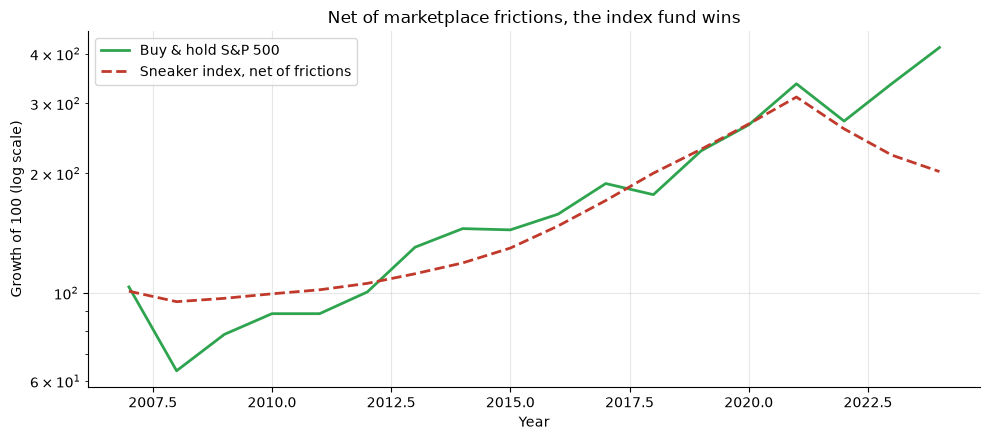

Terminal: S&P 415  vs  net sneaker 202 (base 100)


In [6]:
if HAVE_REAL:
    d = df.sort_values('year')
    yrs = d['year'].values
    sn_net = (d['sneaker_return'].values - 0.03)
    sn_cum = np.cumprod(1 + sn_net) * 100
    spx_cum = np.cumprod(1 + d['gspc_return'].values) * 100
else:
    rng = np.random.default_rng(99)
    yrs = np.arange(R['year_start'], R['year_end']+1)
    sn_net = rng.normal((R['net_sneaker_mean_pct'])/100, R['sneaker_vol_pct']/100, R['n'])
    spx = rng.normal(R['gspc_mean_pct']/100, R['gspc_vol_pct']/100, R['n'])
    sn_cum = np.cumprod(1 + sn_net) * 100
    spx_cum = np.cumprod(1 + spx) * 100

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(yrs, spx_cum, lw=2, c=GREEN, label='Buy & hold S&P 500')
ax.plot(yrs, sn_cum, lw=2, c=RED, ls='--', label='Sneaker index, net of frictions')
ax.set_yscale('log'); ax.set_xlabel('Year')
ax.set_ylabel('Growth of 100 (log scale)')
ax.set_title('Net of marketplace frictions, the index fund wins')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Terminal: S&P {spx_cum[-1]:.0f}  vs  net sneaker {sn_cum[-1]:.0f} (base 100)')

> Net of a conservative friction the un-buyable sneaker index trails a plain index fund -- and that comparison still credits the sneaker leg with its *understated* (smoothed) volatility. On true risk it is strictly worse.

## 7 - Going further -- the synthetic positive control

Does the engine detect a sneaker alpha *when one exists*, and does planted smoothing reproduce the Sharpe illusion? We sweep both knobs.

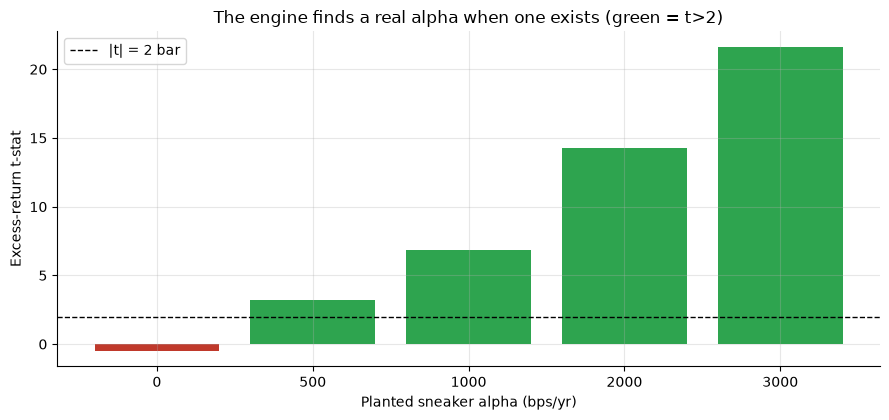

 alpha_bps  excess_%  t_excess
         0     -0.71     -0.52
       500      4.29      3.17
      1000      9.29      6.87
      2000     19.29     14.26
      3000     29.29     21.65

Smoothing-only control (alpha=0, rho=0.6): reported Sharpe 0.66 vs unsmoothed 0.34 -- inflated by smoothing, exactly as on the real tape.


In [7]:
alphas = [0, 500, 1000, 2000, 3000]
rows = []
for a in alphas:
    dfa, _ = data.synthetic_panel(n_years=400, alpha_bps=float(a), smooth_rho=0.0, seed=276)
    ca = st.compare_returns(dfa)
    rows.append({'alpha_bps': a, 'excess_%': ca['excess_mean']*100,
                 't_excess': ca['excess_t_ols']})
ctrl = pd.DataFrame(rows)

# Smoothing illusion with ZERO alpha
df_sm, _ = data.synthetic_panel(n_years=400, alpha_bps=0.0, smooth_rho=0.6, seed=276)
csm = st.compare_returns(df_sm)

fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols = [GREEN if t>2 else RED for t in ctrl['t_excess']]
ax.bar(ctrl['alpha_bps'].astype(str), ctrl['t_excess'], color=cols)
ax.axhline(2, ls='--', c='k', lw=1, label='|t| = 2 bar')
ax.set_xlabel('Planted sneaker alpha (bps/yr)'); ax.set_ylabel('Excess-return t-stat')
ax.set_title('The engine finds a real alpha when one exists (green = t>2)')
ax.legend(); plt.tight_layout(); plt.show()
print(ctrl.round(2).to_string(index=False))
print()
print(f"Smoothing-only control (alpha=0, rho=0.6): reported Sharpe {csm['sneaker_sharpe']:.2f} "
      f"vs unsmoothed {csm['unsmoothed_sharpe']:.2f} -- inflated by smoothing, exactly as on the real tape.")

The engine cleanly detects a planted alpha once it is large enough, and planted AR(1) smoothing reproduces the reported-vs-unsmoothed Sharpe gap we see on the real index. The null verdict is therefore a statement about the **sneaker market and its pricing**, not about the method.